<a href="https://colab.research.google.com/github/sivasooryagiri/Learn-PyTorch-for-deep-learning-in-a-day--Notes/blob/main/01_Putting_it_all_together.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing PyTorch and matplotlib
import torch
from torch import nn
import matplotlib.pyplot as plt

In [ ]:
# Crating Divice-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using Divice: {device}")

Using Divice: cuda


# Data


In [ ]:
weight = 0.7
bias = 0.1

# Create a range of values
start = 0
end = 1
step = 0.02

# Create X and y (features and labels)
X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight * X +bias


In [ ]:
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.1000],
         [0.1140],
         [0.1280],
         [0.1420],
         [0.1560],
         [0.1700],
         [0.1840],
         [0.1980],
         [0.2120],
         [0.2260]]))

In [ ]:
# Split Data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(y_train), len(X_test)

(40, 10)

In [ ]:
#plot the data
def plot_predictions(train_data = X_train,
                     train_labels = y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     predictions = None):
  plt.figure(figsize=(10,7))
  plt.scatter(train_data, train_labels, c="b", s=4, label="Testing data")
  plt.scatter(test_data, test_labels, c="g", s=4, label="Training data")
  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
  plt.legend(prop={"size":14})

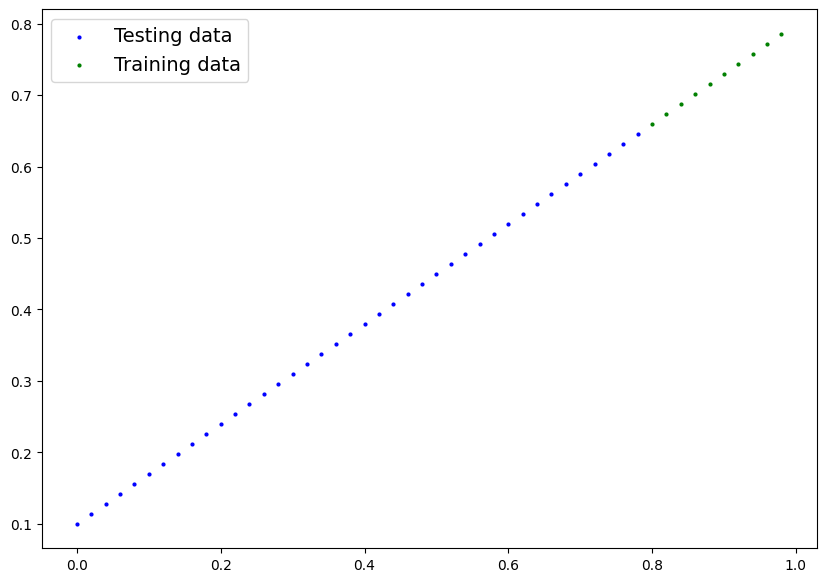

In [ ]:
plot_predictions()

In [ ]:
# Bulding the model

In [ ]:
class LineatRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.linear_layer = nn.Linear(in_features=1,
                                  out_features=1)
  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)


In [ ]:
torch.manual_seed(42)
model_1 = LineatRegressionModel()
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [ ]:
model_1.to(device)

LineatRegressionModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [ ]:
next(model_1.parameters())

Parameter containing:
tensor([[0.7645]], device='cuda:0', requires_grad=True)

Training

In [ ]:
loss_fn = nn.L1Loss()
optimizer =torch.optim.SGD(params=model_1.parameters() ,lr=0.01)

In [ ]:
torch.manual_seed(42)
epochs = 200

# Move data to the target device
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)


for epoch in range(epochs):
  model_1.train()
  y_pred = model_1(X_train)
  loss = loss_fn(y_pred,y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  #Testing
  model_1.eval()
  with torch.inference_mode():
    test_pred = model_1(X_test)
    test_loss = loss_fn(test_pred, y_test)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Loss: 0.003631075844168663 | Test loss: 0.005814731121063232
Epoch: 10 | Loss: 0.003631075844168663 | Test loss: 0.005814731121063232
Epoch: 20 | Loss: 0.003631075844168663 | Test loss: 0.005814731121063232
Epoch: 30 | Loss: 0.003631075844168663 | Test loss: 0.005814731121063232
Epoch: 40 | Loss: 0.003631075844168663 | Test loss: 0.005814731121063232
Epoch: 50 | Loss: 0.003631075844168663 | Test loss: 0.005814731121063232
Epoch: 60 | Loss: 0.003631075844168663 | Test loss: 0.005814731121063232
Epoch: 70 | Loss: 0.003631075844168663 | Test loss: 0.005814731121063232
Epoch: 80 | Loss: 0.003631075844168663 | Test loss: 0.005814731121063232
Epoch: 90 | Loss: 0.003631075844168663 | Test loss: 0.005814731121063232
Epoch: 100 | Loss: 0.003631075844168663 | Test loss: 0.005814731121063232
Epoch: 110 | Loss: 0.003631075844168663 | Test loss: 0.005814731121063232
Epoch: 120 | Loss: 0.003631075844168663 | Test loss: 0.005814731121063232
Epoch: 130 | Loss: 0.003631075844168663 | Test lo

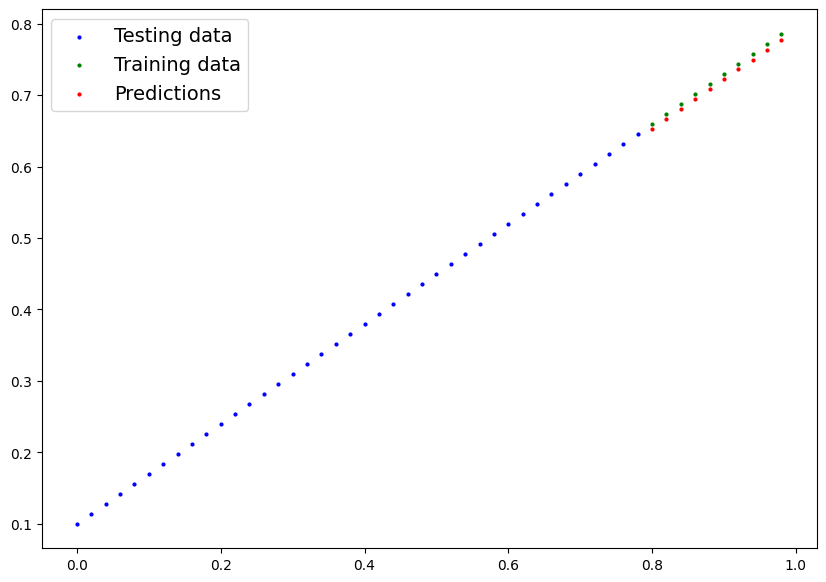

In [ ]:
model_1.eval()
with torch.inference_mode():
  y_preds = model_1(X_test)

y_preds_cpu = y_preds.to('cpu')
plot_predictions(predictions=test_pred)

In [ ]:
# Saving and Loading Models

In [ ]:
from pathlib import Path
# Model Directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
# Model Path
MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
MODEL_SAVE_PATH
# saving the model
torch.save(obj=model_1.state_dict(), f=MODEL_SAVE_PATH)

In [ ]:
# Load Model
loaded_model = LineatRegressionModel()
# Load Sate Dict
loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH))
loaded_model.to(device)

LineatRegressionModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)